# AR(2)-HMM: Streaming Inference Demo

This notebook demonstrates the streaming HMM with **AR(2) emission models** and
known noise variance. Each regime has its own AR(2) coefficient vector
$\boldsymbol\phi^{(k)} = [\phi_1^{(k)},\, \phi_2^{(k)}]$, which we learn online
using Bayesian linear regression updates.

**Model:**
$$
\begin{aligned}
    p(s_t \mid s_{t-1}) &= \pi_{s_t,\,s_{t-1}} \quad\text{(known)}\\
    \boldsymbol\phi^{(k)} &\sim \mathcal{N}(\mathbf{m}_0,\, \boldsymbol\Sigma_0)\\
    y_t \mid s_t{=}k &= \boldsymbol\phi^{(k)\top} \mathbf{x}_t + \varepsilon_t,
    \quad \varepsilon_t \sim \mathcal{N}(0,\, \sigma^2)
\end{aligned}
$$
where $\mathbf{x}_t = [y_{t-1},\, y_{t-2}]^\top$.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
from streaming_hmm import (
    run_streaming_hmm,
    ar_update_fn,
    ar_forecast_fn,
    init_ar_particles,
    build_weights,
)

In [2]:
# Configure matplotlib
%config InlineBackend.figure_format = "retina"
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (7, 3.0)
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "serif"

sns.set_palette("colorblind")
colors = sns.color_palette()

## Data Generation

We generate data from a 3-regime AR(2)-HMM, each regime having distinct
dynamics:

| Regime | $\phi_1$ | $\phi_2$ | Character |
|--------|----------|----------|-----------|
| 0      | 0.9      | 0.0      | Strong persistence |
| 1      | -0.6     | 0.0      | Alternating / mean-reverting |
| 2      | 0.2      | 0.6      | Smooth oscillations |

In [19]:
key = jax.random.PRNGKey(42)
key_sample, key_run = jax.random.split(key)

# HMM transition matrix (high self-transition)
n_regimes = 3
diag_val = 0.99
transition_matrix = (
    jnp.ones((n_regimes, n_regimes)) * (1 - diag_val) / (n_regimes - 1)
)
transition_matrix = transition_matrix.at[jnp.diag_indices(n_regimes)].set(diag_val)
log_transition_matrix = jnp.log(transition_matrix)

# AR(2) coefficients per regime
# ar_coeffs = jnp.array([
#     [ 0.9,  0.0],   # Regime 0: strong persistence
#     [-0.6,  0.0],   # Regime 1: alternating
#     [ 0.2,  0.6],   # Regime 2: smooth oscillations
# ])

ar_coeffs = jnp.array([
    [ 0.6,  0.2],   # Regime 0: persistent trending differences (smooth macro drift)
    [ 1.4, -0.6],   # Regime 1: oscillatory differences (cyclical trend)
    [ 0.5,  0.3],   # Regime 2: stable moderate persistence
])


obs_var = 0.5

In [20]:
# Data generation
def ar2_step(carry, key):
    y_prev1, y_prev2, state = carry
    key_state, key_noise = jax.random.split(key)

    # Regime transition
    state_next = jax.random.choice(key_state, n_regimes, p=transition_matrix[state])

    # AR(2) observation
    phi = ar_coeffs[state_next]
    y_mean = phi[0] * y_prev1 + phi[1] * y_prev2
    y = y_mean + jax.random.normal(key_noise) * jnp.sqrt(obs_var)

    return (y, y_prev1, state_next), (state_next, y)


n_steps = 1500
timesteps = jnp.arange(n_steps)
keys = jax.random.split(key_sample, n_steps)
_, (states, obs) = jax.lax.scan(ar2_step, (0.0, 0.0, 0), keys)

In [21]:
# Regime change indices (for background shading)
regime_changes_ix = jnp.where(jnp.diff(states) != 0)[0]
regime_changes_ix = jnp.insert(regime_changes_ix, 0, 0)
regime_changes_ix = jnp.append(regime_changes_ix, n_steps - 1)

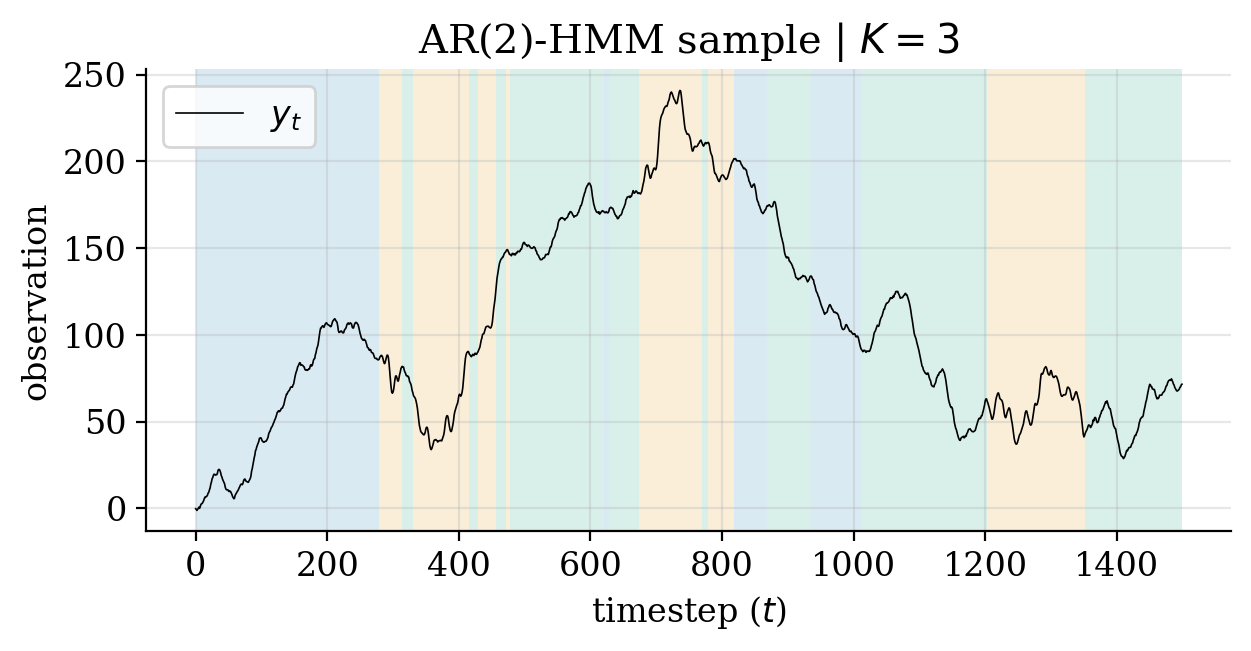

In [22]:
# Plot generated data
fig, ax = plt.subplots()
for iinit, iend in zip(regime_changes_ix[:-1], regime_changes_ix[1:]):
    ax.axvspan(iinit, iend, color=colors[states[iend]], alpha=0.15, linewidth=0)

ax.plot(obs.cumsum(), c="black", linewidth=0.6, label="$y_t$")

ax.set_xlabel("timestep ($t$)")
ax.set_ylabel("observation")
ax.set_title("AR(2)-HMM sample | $K=3$")
ax.legend()
ax.grid(alpha=0.3)

## Construct Feature Vectors

For an AR(2) model we need $\mathbf{x}_t = [y_{t-1},\, y_{t-2}]^\top$.
We pad the first entries with zeros (cold start).

In [23]:
# Build lagged feature matrix X: (T, 2)
y_lag1 = jnp.concatenate([jnp.zeros(1), obs[:-1]])
y_lag2 = jnp.concatenate([jnp.zeros(2), obs[:-2]])
X = jnp.stack([y_lag1, y_lag2], axis=-1)

# obs_inputs for scan: (y_t, x_t) at each step
obs_inputs = (obs, X)

## Run Streaming HMM with AR(2) Updates

In [24]:
n_particles = 10
ar_order = 2

# Prior over AR coefficients: N(0, I)
mean_init = jnp.zeros(ar_order)
cov_init = jnp.eye(ar_order) * 1.0

key_init, key_eval = jax.random.split(key_run)

bel_init = init_ar_particles(
    key_init, mean_init, cov_init, n_particles, n_regimes, n_steps
)

bel_final, (hist_lw, hist_mean, hist_variance, hist_forecast), hist_weights = run_streaming_hmm(
    obs=obs_inputs,
    transition_matrix=transition_matrix,
    log_transition_matrix=log_transition_matrix,
    bel_init=bel_init,
    update_fn=ar_update_fn,
    forecast_fn=ar_forecast_fn,
    var_obs=obs_var,
)

## Results

### Learned AR Coefficients

The algorithm should converge to the true $\phi_1^{(k)}$, $\phi_2^{(k)}$ for each regime.

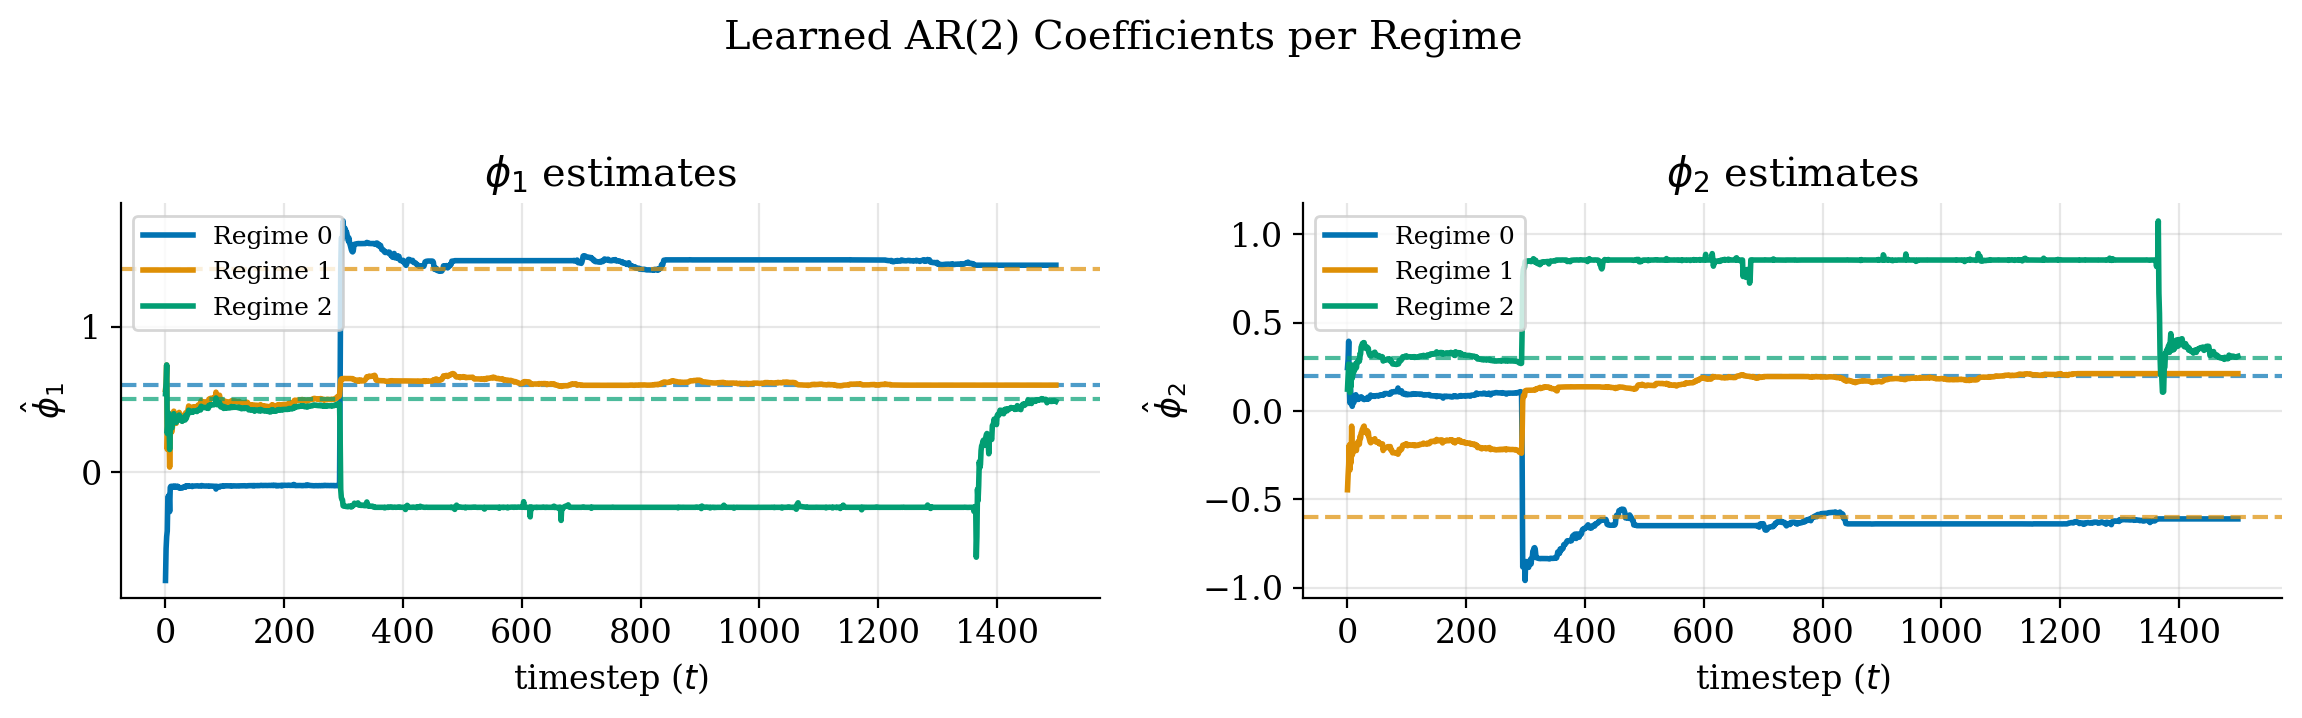

In [25]:
# Weighted mean of AR coefficients: (T, K, D)
coeff_est = jnp.einsum("ts,tskd->tkd", hist_weights, hist_mean)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharex=True)

for d, ax in enumerate(axes):
    for k in range(n_regimes):
        ax.plot(coeff_est[:, k, d], color=colors[k], linewidth=2,
                label=f"Regime {k}")
        ax.axhline(y=ar_coeffs[k, d], color=colors[k], linestyle="--",
                   alpha=0.7)
    ax.set_title(rf"$\phi_{d+1}$ estimates")
    ax.set_xlabel("timestep ($t$)")
    ax.set_ylabel(rf"$\hat\phi_{d+1}$")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

fig.suptitle("Learned AR(2) Coefficients per Regime", y=1.03)
plt.tight_layout()

### Regime Detection

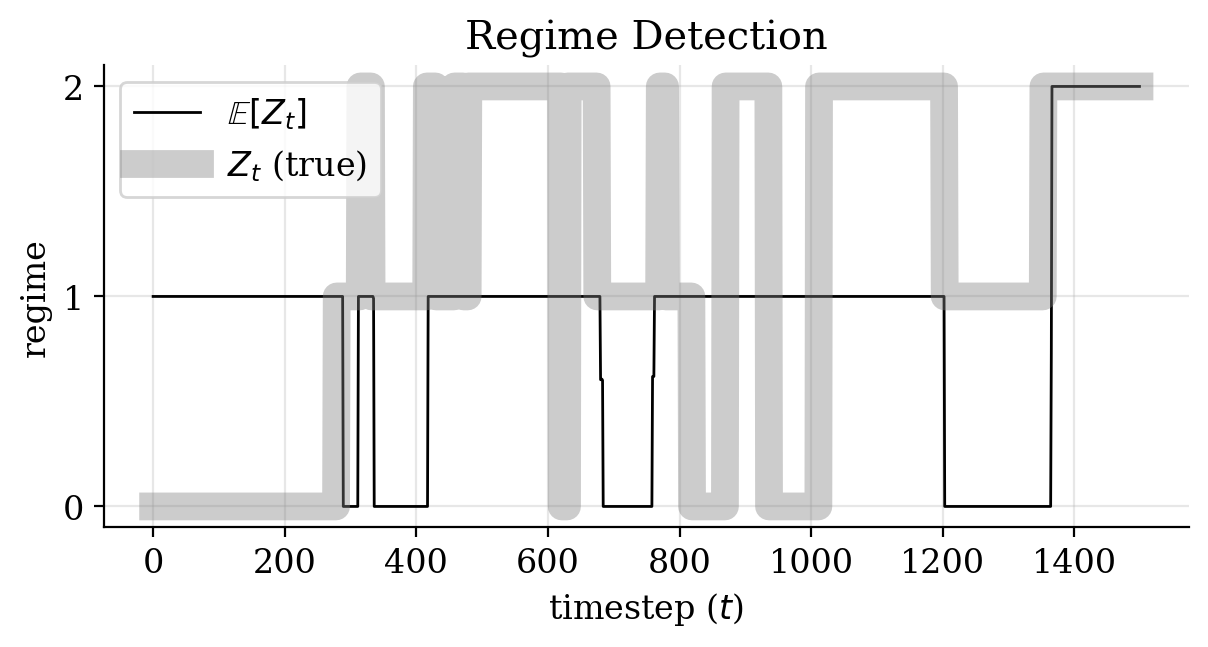

In [26]:
# Regime probabilities from final particle paths
hist_regimes_ohe = jax.nn.one_hot(bel_final.regime, n_regimes, axis=0)

proba_regimes = jnp.einsum("kst,ts->tk", hist_regimes_ohe, hist_weights)
path_exp = jnp.einsum("tk,k->t", proba_regimes, jnp.arange(n_regimes).astype(float))

plt.plot(path_exp, c="black", linewidth=1, label=r"$\mathbb{E}[Z_t]$")
plt.plot(states, c="gray", linewidth=10, alpha=0.4, label="$Z_t$ (true)")
plt.legend()
plt.yticks(jnp.arange(n_regimes))
plt.xlabel("timestep ($t$)")
plt.ylabel("regime")
plt.title("Regime Detection")
plt.grid(alpha=0.3)

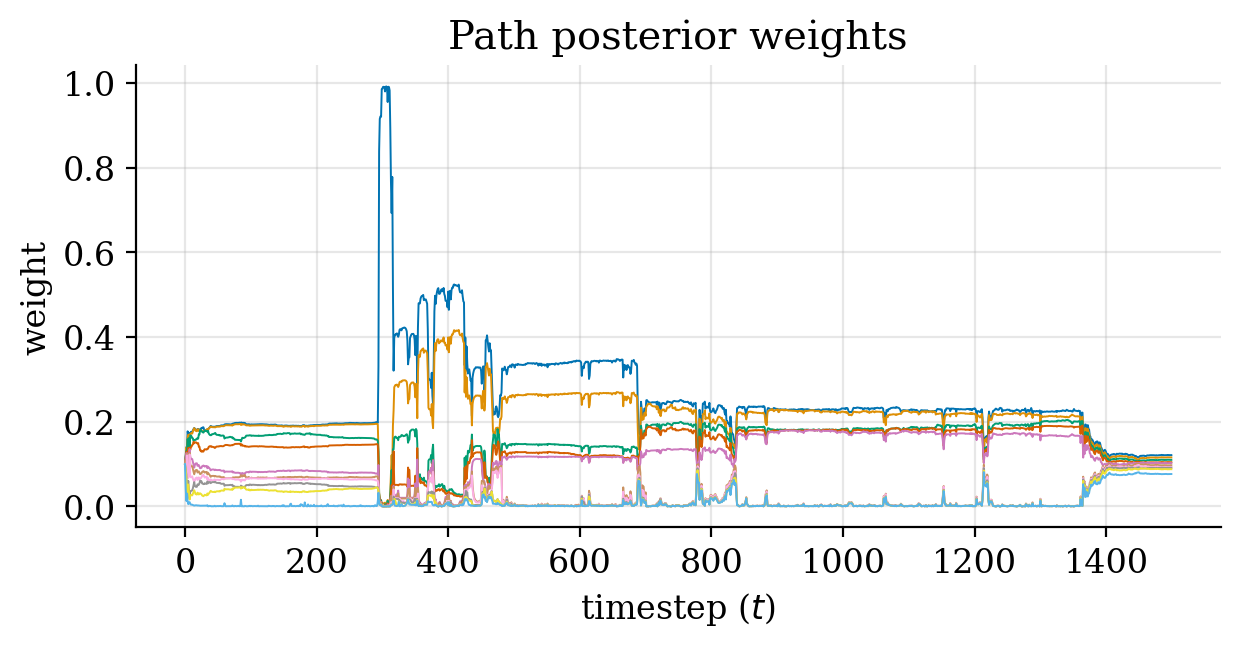

In [27]:
# Particle weights over time
plt.title("Path posterior weights")
plt.plot(hist_weights, linewidth=0.7)
plt.xlabel("timestep ($t$)")
plt.ylabel("weight")
plt.grid(alpha=0.3)

In [28]:
print(f"Minimum weight: {hist_weights.min():.6f}")

Minimum weight: 0.000012


### Filtered Estimates

The filtered mean is the one-step prediction using the *current* regime
assignment and learned AR coefficients.

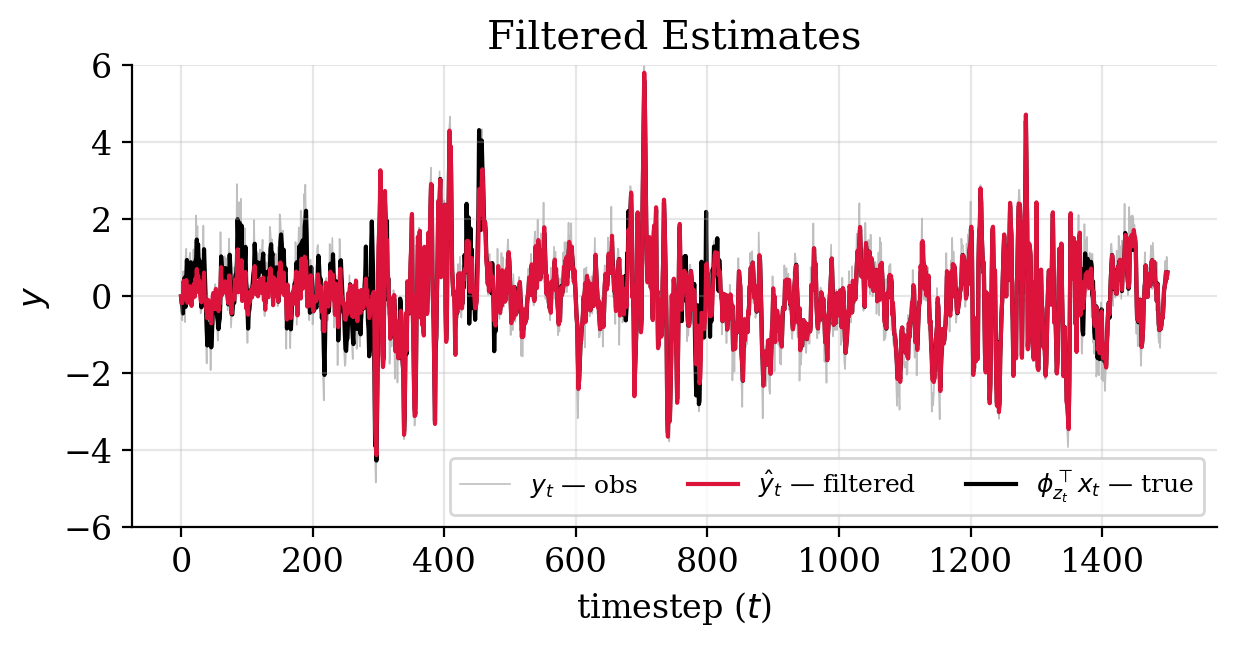

In [29]:
# Compute true AR prediction (using true coefficients and true regimes)
true_pred = jnp.sum(ar_coeffs[states] * X, axis=-1)  # (T,)

# Filtered estimate from particles: weighted predicted means
# For each particle s at time t, the prediction under the assigned regime is x^T m_{s,k}
# We use the regime history and weights to compute the weighted prediction
filtered_yhats = jnp.einsum("d,tskd->tsk", jnp.zeros(ar_order), hist_mean)  # placeholder

# Actually compute per-particle predictions using features and learned means
# hist_mean: (T, S, K, D), X: (T, 2)
# For each (t, s), the assigned regime is bel_final.regime[s, t]
particle_pred = jnp.einsum("td,tskd->tsk", X, hist_mean)  # (T, S, K)
filtered_est = jnp.einsum(
    "tsk,kst,ts->t",
    particle_pred,
    hist_regimes_ohe,
    hist_weights
)

plt.plot(obs, c="gray", alpha=0.5, linewidth=0.6, label="$y_t$ — obs", zorder=0)
plt.plot(filtered_est, c="crimson", linewidth=1.5, label=r"$\hat{y}_t$ — filtered")
plt.plot(true_pred, c="black", linewidth=1.5, label=r"$\phi_{z_t}^\top x_t$ — true", zorder=1)
plt.legend(fontsize=9, ncol=3)
plt.ylim(-6, 6)
plt.xlabel("timestep ($t$)")
plt.ylabel("$y$")
plt.title("Filtered Estimates")
plt.grid(alpha=0.3)

### Forecast Estimates

One-step-ahead predictions with uncertainty bands.

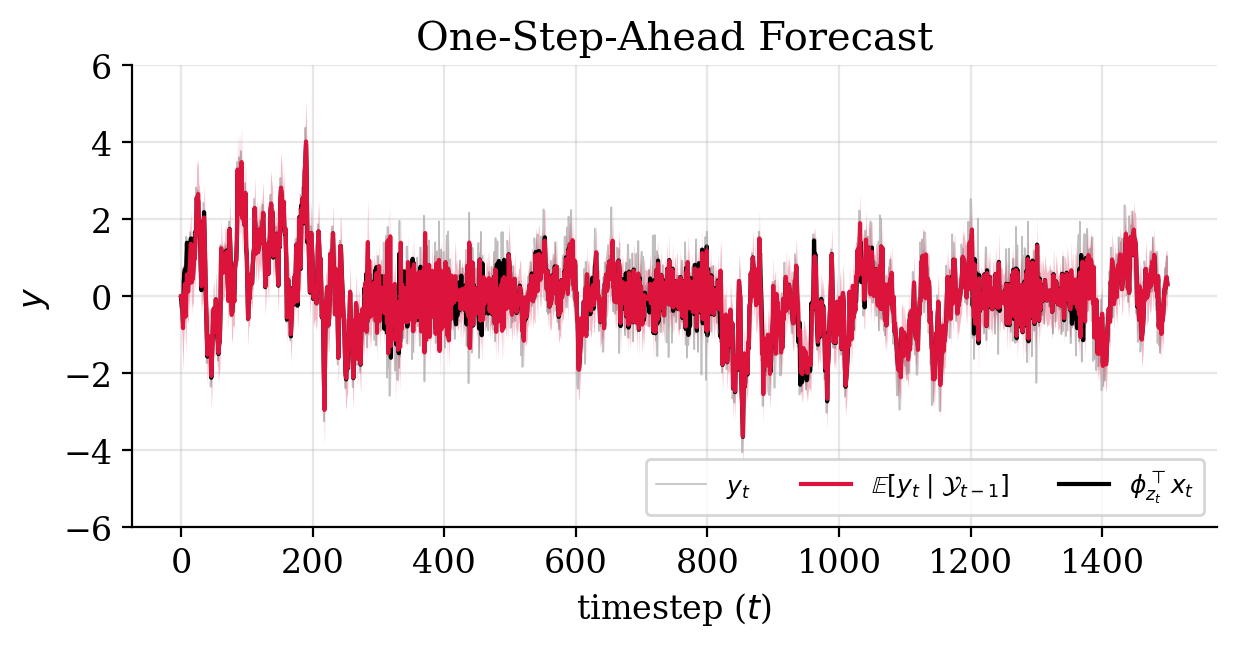

In [14]:
lbound = hist_forecast["mean"] - 1 * hist_forecast["stdev_obs"]
ubound = hist_forecast["mean"] + 1 * hist_forecast["stdev_obs"]

plt.fill_between(timesteps, lbound, ubound, color="crimson", alpha=0.3, linewidth=0)
plt.plot(obs, c="gray", alpha=0.5, linewidth=0.6, label="$y_t$", zorder=0)
plt.plot(hist_forecast["mean"], c="crimson", linewidth=1.5,
         label=r"$\mathbb{E}[y_{t} \mid \mathcal{Y}_{t-1}]$")
plt.plot(true_pred, c="black", linewidth=1.5, zorder=1,
         label=r"$\phi_{z_t}^\top x_t$")
plt.legend(fontsize=9, ncol=3, loc="lower right")
plt.ylim(-6, 6)
plt.xlabel("timestep ($t$)")
plt.ylabel("$y$")
plt.title("One-Step-Ahead Forecast")
plt.grid(alpha=0.3)

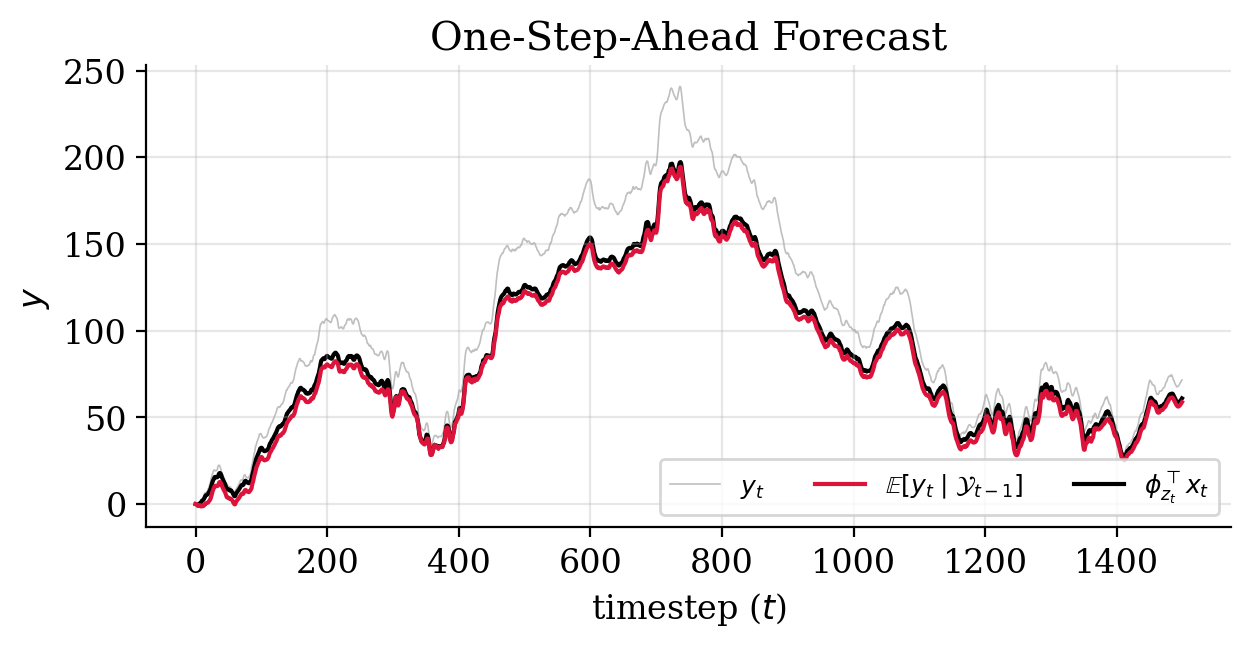

In [32]:
lbound = hist_forecast["mean"] - 1 * hist_forecast["stdev_obs"]
ubound = hist_forecast["mean"] + 1 * hist_forecast["stdev_obs"]

# plt.fill_between(timesteps, lbound, ubound, color="crimson", alpha=0.3, linewidth=0)
plt.plot(obs.cumsum(), c="gray", alpha=0.5, linewidth=0.6, label="$y_t$", zorder=0)
plt.plot(hist_forecast["mean"].cumsum(), c="crimson", linewidth=1.5,
         label=r"$\mathbb{E}[y_{t} \mid \mathcal{Y}_{t-1}]$")
plt.plot(true_pred.cumsum(), c="black", linewidth=1.5, zorder=1,
         label=r"$\phi_{z_t}^\top x_t$")
plt.legend(fontsize=9, ncol=3, loc="lower right")
# plt.ylim(-6, 6)

plt.xlabel("timestep ($t$)")
plt.ylabel("$y$")
plt.title("One-Step-Ahead Forecast")
plt.grid(alpha=0.3)

### Forecast Error Analysis

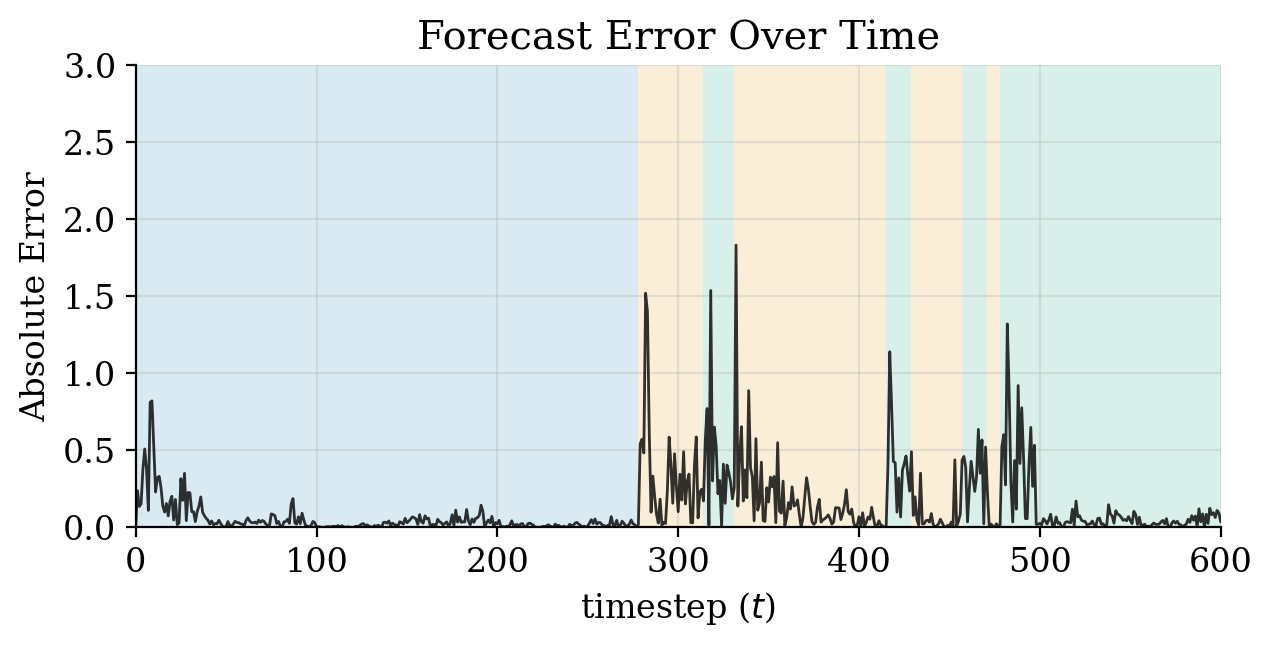

In [15]:
yhat = hist_forecast["mean"]
diff_abs = jnp.abs(yhat - true_pred)

for iinit, iend in zip(regime_changes_ix[:-1], regime_changes_ix[1:]):
    plt.axvspan(iinit, iend, color=colors[states[iend]], alpha=0.15, linewidth=0)

plt.plot(diff_abs, c="black", linewidth=1, alpha=0.8)
plt.ylim(0, 3)
plt.xlim(0, 600)
plt.xlabel("timestep ($t$)")
plt.ylabel("Absolute Error")
plt.title("Forecast Error Over Time")
plt.grid(alpha=0.3)

### Zoomed-in Views

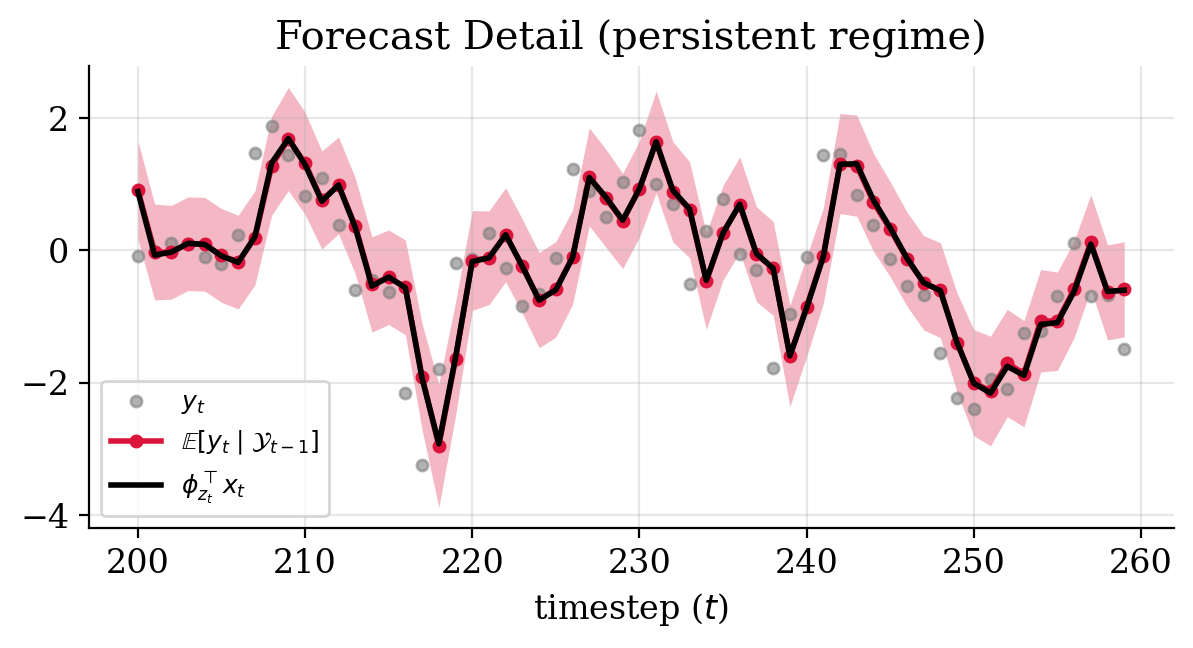

In [16]:
# Zoomed view — persistent regime region
tslice = slice(200, 260)
plt.fill_between(timesteps[tslice], lbound[tslice], ubound[tslice],
                 color="crimson", alpha=0.3, linewidth=0)
plt.plot(timesteps[tslice], obs[tslice], c="gray", alpha=0.6,
         marker="o", linewidth=0, markersize=4, label="$y_t$")
plt.plot(timesteps[tslice], hist_forecast["mean"][tslice], c="crimson",
         linewidth=2, marker="o", markersize=4,
         label=r"$\mathbb{E}[y_t \mid \mathcal{Y}_{t-1}]$")
plt.plot(timesteps[tslice], true_pred[tslice], c="black", linewidth=2,
         label=r"$\phi_{z_t}^\top x_t$")
plt.legend(fontsize=9)
plt.xlabel("timestep ($t$)")
plt.title("Forecast Detail (persistent regime)")
plt.grid(alpha=0.3)

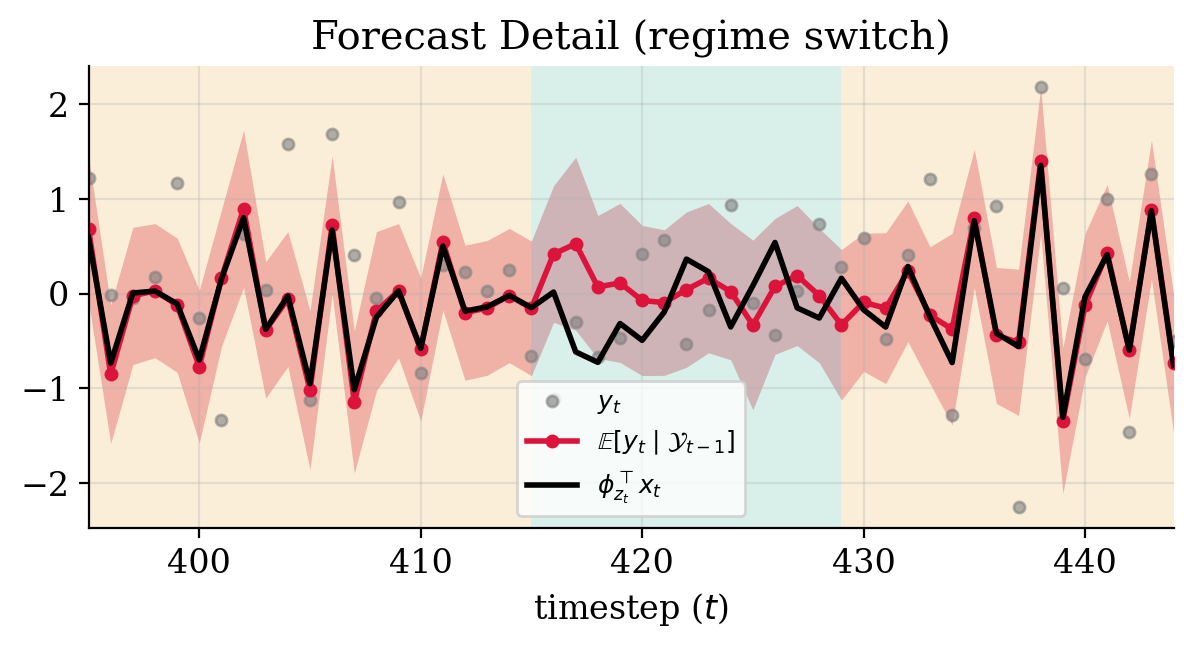

In [17]:
# Zoomed view — regime-switching region
# Find a region with a regime change
change_idx = int(regime_changes_ix[4])
tslice = slice(max(0, change_idx - 20), change_idx + 30)
plt.fill_between(timesteps[tslice], lbound[tslice], ubound[tslice],
                 color="crimson", alpha=0.3, linewidth=0)
plt.plot(timesteps[tslice], obs[tslice], c="gray", alpha=0.6,
         marker="o", linewidth=0, markersize=4, label="$y_t$")
plt.plot(timesteps[tslice], hist_forecast["mean"][tslice], c="crimson",
         linewidth=2, marker="o", markersize=4,
         label=r"$\mathbb{E}[y_t \mid \mathcal{Y}_{t-1}]$")
plt.plot(timesteps[tslice], true_pred[tslice], c="black", linewidth=2,
         label=r"$\phi_{z_t}^\top x_t$")
for iinit, iend in zip(regime_changes_ix[:-1], regime_changes_ix[1:]):
    plt.axvspan(iinit, iend, color=colors[states[iend]], alpha=0.15, linewidth=0)
plt.xlim(timesteps[tslice][0], timesteps[tslice][-1])
plt.legend(fontsize=9)
plt.xlabel("timestep ($t$)")
plt.title("Forecast Detail (regime switch)")
plt.grid(alpha=0.3)